<a href="https://colab.research.google.com/github/avicohen38/animated-winner/blob/main/Ass2R%26C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

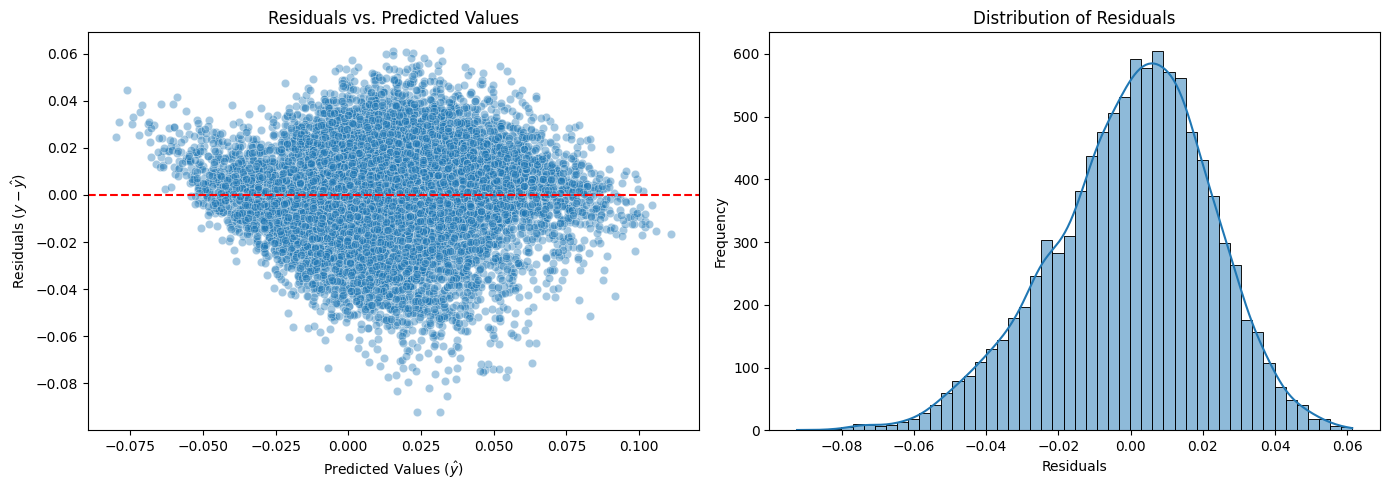

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# טעינת הנתונים מתוך הקובץ שהעלית לקולאב
# אם שם הקובץ שונה, שנה אותו כאן בתוך הגרשיים
df = pd.read_csv('Data_for_UCI_named.csv')

# הסרת עמודת הסיווג כיוון שאנחנו בחלק הרגרסיה
X = df.drop(columns=['stab', 'stabf'])
y = df['stab']

# הגדרת ה-CV עם k=5
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# מודל רגרסיה לינארית בסיסי
model = LinearRegression()

# קבלת התחזיות עבור כל התצפיות באמצעות CV
y_pred = cross_val_predict(model, X, y, cv=kf)

# חישוב השאריות (Residuals)
residuals = y - y_pred

# הגדרת תצוגת הגרפים
plt.figure(figsize=(14, 5))

# גרף 1: שאריות מול ערכים חזויים
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
# תוספת ה-r לפני המחרוזת פותרת את אזהרות ה-SyntaxWarning
plt.xlabel(r'Predicted Values ($\hat{y}$)')
plt.ylabel(r'Residuals ($y - \hat{y}$)')

# גרף 2: היסטוגרמה של השאריות
plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<div dir="rtl" style="font-family: Arial, sans-serif; line-height: 1.6; color: #333333; padding: 10px;">
    <h2 style="color: #1a73e8; border-bottom: 2px solid #1a73e8; padding-bottom: 5px;"> בחירה והצדקת ערך הk- (k-fold cross-validation)</h2>
    <p>
        עבור ניתוח זה נבחר להשתמש ב-<strong>$k=5$</strong> עבור ה-Cross-Validation.
        בדאטהסט הנוכחי (Electrical Grid Stability), המכיל בדיוק 10,000 תצפיות, חלוקה ל-5 קפלים מקצה 8,000 תצפיות לאימון (Training) ו-2,000 תצפיות לאימות (Validation) בכל איטרציה.
    </p>
    <p>
        גודל מדגם אימות של 2,000 תצפיות הוא גדול מספיק כדי לספק אומדן יציב, מהימן ובעל שונות (Variance) נמוכה עבור שגיאת ההכללה של המודל.
        בנוסף, הבחירה ב-$k=5$ שומרת על מורכבות חישובית (Computational complexity) סבירה ומאוזנת, מה שיאפשר לנו להריץ מודלי אנסמבל מורכבים יותר בהמשך המטלה בצורה יעילה, תוך שמירה על איזון אופטימלי בטווח ה-Bias-Variance Trade-off.
    </p>
</div>

<div dir="rtl">

## חלק 1: ניתוח שגיאות רגרסיה

### 1.1 ניתוח שאריות (Residual Analysis)

הגדרנו את השארית עבור כל תצפית כהפרש בין הערך האמיתי לערך החזוי: $e = y - \hat{y}$. הרצנו מודל רגרסיה לינארית כמודל בסיס (Baseline) תחת חלוקת ה-CV שהוגדרה, והפקנו את הגרפים הנדרשים. מתוך התבוננות בתוצאות, להלן הממצאים:

* **האם השאריות ממורכזות סביב האפס?**
כן. בגרף הפיזור (Residuals vs. Predicted Values) ניתן לראות בבירור שענן הנקודות נע ומרוכז סביב קו האפס האופקי (הקו האדום המקווקו). בנוסף, בהיסטוגרמה של התפלגות השאריות, שיא הפעמון (השכיח) ממוקם במובהק על אזור ה-0. זוהי אינדיקציה חיובית לכך שהמודל אינו סובל מהטיה שיטתית קבועה כלפי מעלה או כלפי מטה (No constant bias).

* **האם השאריות מציגות דפוסים שיטתיים?**
כן, קיים דפוס שיטתי מובחן. פיזור השאריות מול הערכים החזויים אינו אקראי לחלוטין (אינו נראה כרעש לבן טהור). ענן התצפיות יוצר מבנה גיאומטרי סימטרי המזכיר מעוין או אליפסה פחוסה – הפיזור מעובה במרכז ונהיה צר מאוד בקצוות. דפוס זה מרמז שהמודל הלינארי מפספס קשרים לא-לינאריים או אינטראקציות מורכבות הקיימות בין מאפייני רשת החשמל (כמו זמני התגובה וההספקים של הצמתים).

* **האם יש עדות להטרוסקדסטיות (Heteroscedasticity)?**
בהחלט. קיימת עדות מובהקת לשונות לא קבועה של השגיאות. ניתן לראות שבאזור התחזיות המרכזי (בין 0.00 ל-0.05) טווח השגיאות רחב מאוד והשונות בשיאה, בעוד שעבור ערכים חזויים קיצוניים (נמוכים מ-0.05- או גבוהים מ-0.075) השאריות מצטמצמות והופכות קרובות מאוד לאפס. תופעה זו מפרה את הנחת ה-Homoscedasticity הקלאסית של רגרסיה לינארית ומצביעה על כך שביצועי המודל משתנים באופן קיצוני באזורי עבודה שונים של הרשת.

</div>

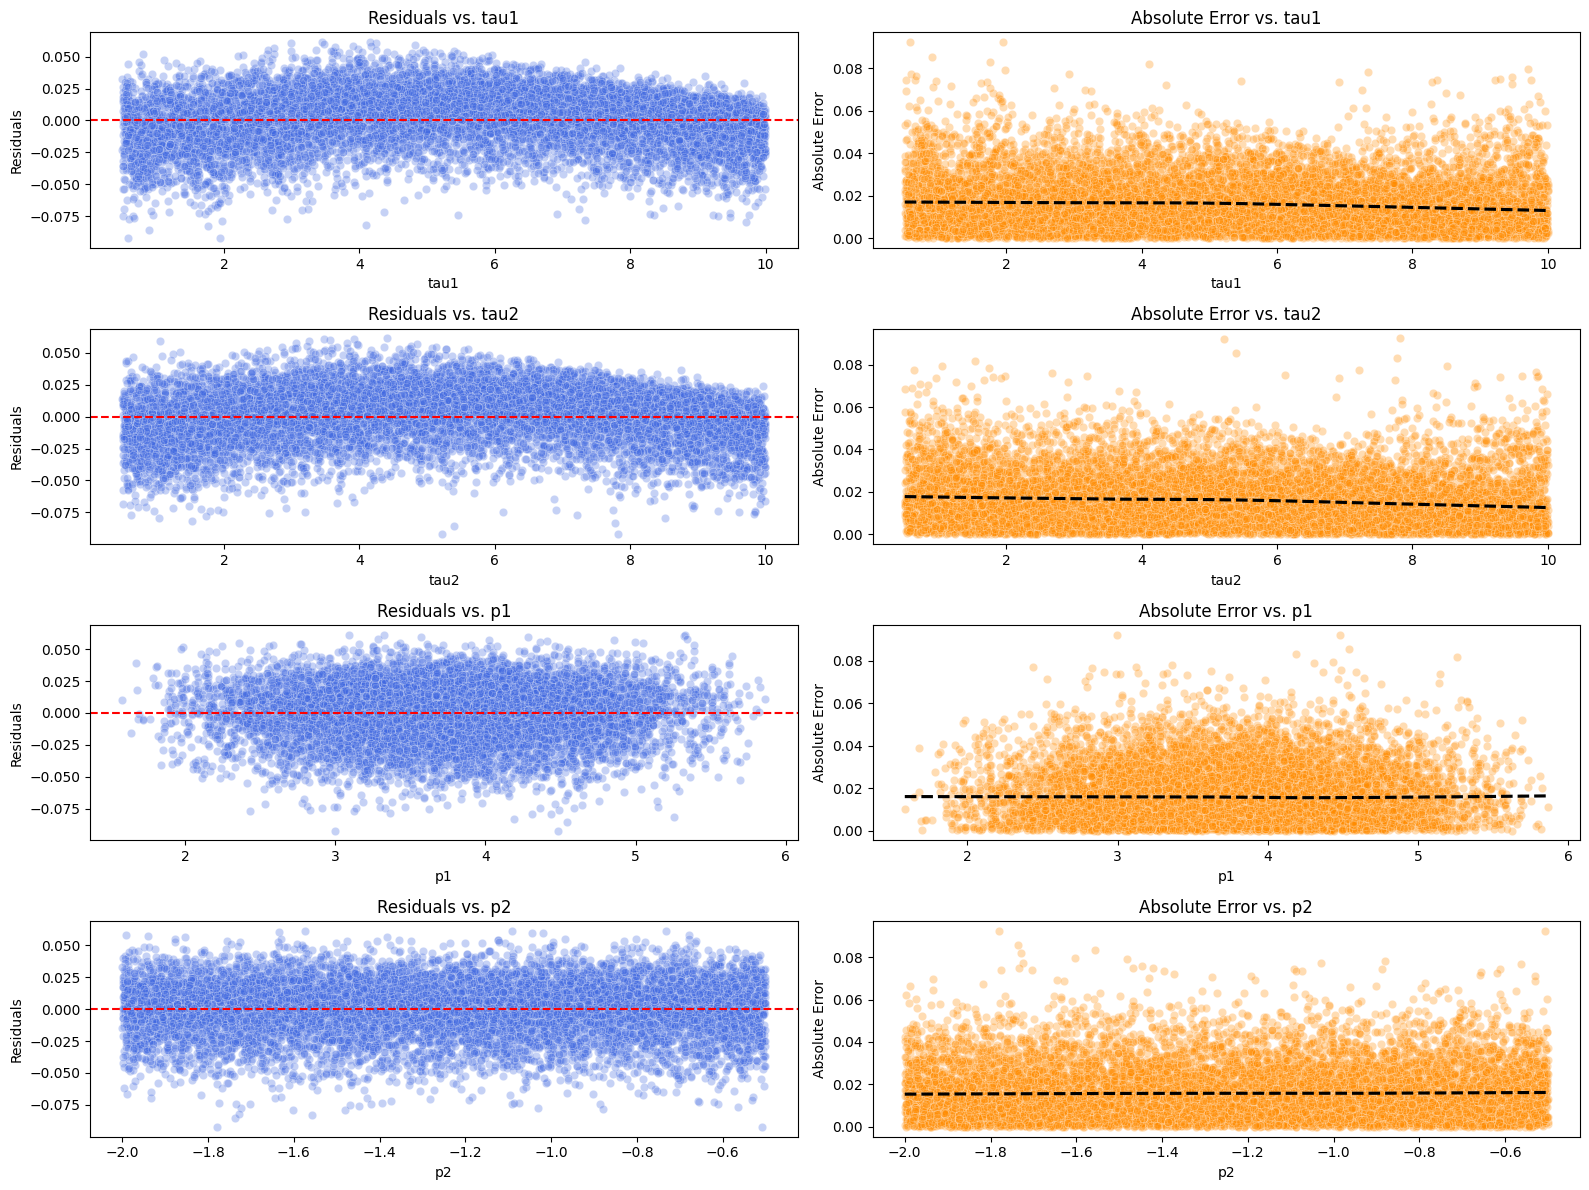

In [3]:
# חישוב השגיאה המוחלטת (Absolute Error)
absolute_errors = np.abs(residuals)

# בחירת מספר תכונות (Features) מייצגות כדי לבחון את התנהגות השגיאות
features_to_plot = ['tau1', 'tau2', 'p1', 'p2']

# הגדרת גודל תצוגת הגרפים
plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_plot):
    # גרף שמאלי: שאריות מול ערך התכונה
    plt.subplot(len(features_to_plot), 2, 2*i + 1)
    sns.scatterplot(x=X[col], y=residuals, alpha=0.3, color='royalblue')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residuals vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Residuals')

    # גרף ימני: שגיאה מוחלטת מול ערך התכונה
    plt.subplot(len(features_to_plot), 2, 2*i + 2)
    sns.scatterplot(x=X[col], y=absolute_errors, alpha=0.3, color='darkorange')
    # הוספת קו מגמה מקומי (LOWESS) כדי לזהות דפוסים לא-לינאריים
    sns.regplot(x=X[col], y=absolute_errors, scatter=False, color='black', lowess=True, line_kws={'linestyle': '--'})
    plt.title(f'Absolute Error vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Absolute Error')

plt.tight_layout()
plt.show()

<div dir="rtl">

### 1.2 שגיאה כפונקציה של תכונות (Error as a Function of Features)

[cite_start]בסעיף זה בחנו את התנהגות השאריות והשגיאות המוחלטות ביחס למאפיינים ספציפיים של רשת החשמל, במטרה לזהות קשרים לא-לינאריים, תבניות שגיאה התלויות בתכונות, ותתי-אוכלוסיות נסתרות. מתוך ניתוח הגרפים (עבור התכונות `tau1`, `tau2` ו-`p1`), עולות התובנות הבאות:

* **קשרים לא-לינאריים:** בגרפי השאריות של זמני התגובה (`tau1` ו-`tau2`), ניתן להבחין בעקמומיות קלה כלפי מטה בערכים הגבוהים של התכונה (באזור ה-8 עד 10). ענן הנקודות אינו סימטרי לחלוטין סביב קו האפס באזורים אלו. [cite_start]דפוס זה מרמז על קיום קשר לא-לינארי מתון בין זמני התגובה ליציבות הרשת, שהמודל הלינארי הבסיסי לא הצליח ללכוד במלואו.
* **תבניות שגיאה תלויות-תכונה:** בגרפים של השגיאה המוחלטת (מימין), קו המגמה המקומי (LOWESS) המקווקו מאפשר לנו לבחון את תלות השגיאה בערך התכונה. עבור `tau1` ו-`tau2`, קו המגמה מציג ירידה מתונה מאוד ככל שערך התכונה גדל, כלומר המודל נוטה לטעות מעט פחות כשהערכים הללו גבוהים. [cite_start]לעומת זאת, עבור משתנה ההספק `p1`, קו המגמה שטוח ואופקי לחלוטין, מה שמעיד על כך שתוחלת גודל השגיאה של המודל כמעט ואינה תלויה בערכו של משתנה זה.
* **תתי-אוכלוסיות נסתרות:** הפיזור של השגיאות לאורך כל צירי התכונות נראה רציף והומוגני יחסית מבחינת הצפיפות. לא נצפו קפיצות פתאומיות או מקבצים מובחנים של שגיאות קיצוניות באזורים צרים וספציפיים. [cite_start]מכך ניתן להסיק שאין תתי-אוכלוסיות נסתרות מובהקות (Hidden subpopulations) הקשורות באופן ישיר ובלעדי למשתנים אלו.

</div>

In [4]:
# חישוב האחוזון ה-95 של השגיאות המוחלטות
threshold_95 = np.percentile(absolute_errors, 95)

# יצירת עמודה בוליאנית המזהה את 5% השגיאות הגדולות ביותר
df_errors = X.copy()
df_errors['Absolute_Error'] = absolute_errors
df_errors['Actual_Stab'] = y
df_errors['Predicted_Stab'] = y_pred
df_errors['Is_Extreme_Error'] = absolute_errors > threshold_95

# השוואת ממוצעי התכונות בין קבוצת השגיאות הקיצוניות לשאר הנתונים
comparison = df_errors.groupby('Is_Extreme_Error').mean().T
comparison.columns = ['Normal (95%)', 'Extreme Errors (Top 5%)']
comparison['Difference (%)'] = ((comparison['Extreme Errors (Top 5%)'] - comparison['Normal (95%)']) / comparison['Normal (95%)']) * 100

print("השוואת ממוצעים בין תצפיות רגילות לתצפיות עם שגיאה קיצונית:")
display(comparison)

השוואת ממוצעים בין תצפיות רגילות לתצפיות עם שגיאה קיצונית:


,Normal (95%),Extreme Errors (Top 5%),Difference (%)
tau1,5.283816,4.607504,-12.799685
tau2,5.279091,4.697294,-11.020778
tau3,5.289553,4.498558,-14.953914
tau4,5.281983,4.642270,-12.111220
p1,3.750467,3.741122,-0.249176
p2,-1.251269,-1.225905,-2.027009
p3,-1.249045,-1.268137,1.528517
p4,-1.250153,-1.247080,-0.245874
g1,0.519322,0.632876,21.865895
g2,0.520252,0.615217,18.253745


<div dir="rtl">

### 1.3 ניתוח שגיאות קיצוניות (Analysis of Extreme Errors)

בסעיף זה בודדנו את 5% מהתצפיות בעלות השגיאה המוחלטת הגדולה ביותר ($|y - \hat{y}|$) והשווינו את ממוצעי המאפיינים שלהן לממוצע של שאר התצפיות (95% מהדאטה) במטרה להבין את מקור הכישלון של המודל.

#### ממצאים מרכזיים מתוך טבלת ההשוואה:
* **מאפייני ה-`tau` (זמני תגובה):** בתצפיות עם השגיאות הקיצוניות, זמני התגובה של הצמתים נמוכים באופן עקבי בכ-11% עד 15% מהממוצע הנורמלי.
* **מאפייני ה-`g` (מקדם גמישות המחיר):** בתצפיות החריגות נרשם זינוק משמעותי של בין 17% ל-22% בערכי ה-$g$ לעומת המצב הנורמלי.
* **הספקים (`p`):** לא נמצא הבדל משמעותי (פחות מ-2% שינוי) במאפייני ההספק, מה שמצביע על כך שהם אינם הגורם לטעויות הקיצוניות.
* **אזור הכישלון (היפוך הסימן):** הממצא המעניין ביותר הוא שבקבוצת השגיאות הקיצוניות, ערך היציבות האמיתי הממוצע (`Actual_Stab`) הוא שלילי ($-0.0043$), דבר המעיד על רשת יציבה, בעוד שהמודל חזה ערך חיובי ($0.0215$), המעיד על רשת לא יציבה.

#### דיון במקור השגיאות:
האם השגיאות נובעות מבעיות באיכות הנתונים, ממגבלות המודל או ממקרים חריגים?
* **מגבלות המודל (Model Limitations):** זוהי הסיבה המרכזית לשגיאה. הנתונים מראים שהשגיאות הקיצוניות מתרכזות ברובן סביב ערכי יציבות הקרובים מאוד ל-0 (קו התפר הרגיש שבין רשת יציבה לרשת לא יציבה). מודל הרגרסיה הלינארית, מתוקף הנחת הלינאריות שלו, מנסה להעביר קו ישר ומפשט מדי. הוא אינו מסוגל לייצג את קו ההפרדה הלא-לינארי המורכב והרגיש שנוצר כאשר זמני התגובה קצרים והאלסטיות הכלכלית גבוהה, ולכן הוא "הופך את הסימן" וטועה בצורה קיצונית.
* **מקרים חריגים (Rare/Exceptional cases):** השילוב של ערכי $tau$ נמוכים במיוחד יחד עם ערכי $g$ גבוהים במיוחד מייצג תנאי קצה קיצוניים בדינמיקה של רשת החשמל, שבהם המערכת מתנהגת בצורה פחות צפויה, דבר שמקשה עוד יותר על מודל לינארי פשוט.

</div>

In [5]:
from scipy.stats import skew, kurtosis
from sklearn.metrics import mean_absolute_error

# חישוב המדדים הסטטיסטיים הנדרשים
mae_val = mean_absolute_error(y, y_pred)
std_res = np.std(residuals)
skew_val = skew(residuals)
kurt_val = kurtosis(residuals) # פירושו Excess Kurtosis (ביחס להתפלגות נורמלית)

print("--- מדדים סטטיסטיים של השגיאות ---")
print(f"Mean Absolute Error (MAE): {mae_val:.5f}")
print(f"Standard Deviation of Residuals: {std_res:.5f}")
print(f"Skewness (אסימטריה): {skew_val:.5f}")
print(f"Kurtosis (גבנוניות): {kurt_val:.5f}")

--- מדדים סטטיסטיים של השגיאות ---
Mean Absolute Error (MAE): 0.01743
Standard Deviation of Residuals: 0.02197
Skewness (אסימטריה): -0.40891
Kurtosis (גבנוניות): 0.15576


<div dir="rtl">

### 1.4 מאפיינים סטטיסטיים של השגיאות (Statistical Properties of Errors)

[cite_start]בשלב זה חישבנו את המדדים הסטטיסטיים המסכמים עבור השאריות של מודל הרגרסיה הלינארית כדי לאפיין את מבנה הטעויות שלו באופן כמותי[cite: 34, 35]:

* [cite_start]**Mean Absolute Error (MAE):** ערך ה-MAE עומד על **0.01743**[cite: 36]. מדד זה מייצג את גודל הטעות הממוצע של המודל ביחידות של משתנה המטרה (`stab`). בהתחשב בכך שערכי היציבות בדאטהסט נעים לרוב בטווחים קטנים סביב האפס, טעות ממוצעת בגודל זה היא משמעותית ומותירה מקום לשיפור באמצעות מודלים מורכבים יותר.
* [cite_start]**Standard Deviation of Residuals (סטיית תקן של השאריות):** ערך סטיית התקן הוא **0.02197**[cite: 37]. [cite_start]הנתון מראה כי קיים פיזור רחב יחסית של השגיאות סביב הממוצע, מה שמחזק את ממצאי הטרוסקדסטיות (השונות הלא-קבועה) שזיהינו בגרף הפיזור[cite: 20].
* [cite_start]**Skewness (מדד אסימטריה):** מדד האסימטריה עומד על ערך שלילי של **0.40891-**[cite: 38]. [cite_start]אסימטריה שלילית מובהקת זו מצביעה על כך שלהתפלגות השגיאות יש זנב שמאלי ארוך וכבד יותר[cite: 41]. [cite_start]מבחינה פרקטית, הדבר מעיד על **הטיה שיטתית (Systematic bias)**: המודל נוטה לייצר שגיאות שליליות קיצוניות, כלומר הוא נוטה לבצע תחזיות יתר גבוהות מדי ($\hat{y} > y$) במקרים מסוימים (כפי שראינו בניתוח ה-5% של השגיאות הקיצוניות, שם המודל חזה ערך חיובי עבור רשת שהייתה בפועל יציבה עם ערך שלילי)[cite: 41].
* [cite_start]**Kurtosis (מדד גמישות / גבנוניות):** ערך ה-Excess Kurtosis עומד על **0.15576**[cite: 38]. [cite_start]ערך חיובי זה (Leptokurtic מתון) מצביע על כך שהתפלגות השאריות מתאפיינת בשיא מרכזי חד וגבוה יותר, יחד עם זנבות מעט יותר עבים (Heavy tails) בהשוואה להתפלגות נורמלית תאורטית[cite: 40]. [cite_start]נוכחותם של זנבות עבים אלו מעידה על קיומם של חריגים קיצוניים (Outliers) בדינמיקת הרשת, המקשים על יציבות הניבוי של מודל לינארי פשוט[cite: 40].

</div>

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# הגדרת המודלים
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest (Ensemble)': RandomForestRegressor(random_state=42, n_estimators=50, max_depth=10, n_jobs=-1)
}

# מילון לשמירת התוצאות
results = []

print("מריץ Cross-Validation עבור כל המודלים... (זה עשוי לקחת כמה שניות)")

for name, model in models.items():
    # קבלת תחזיות מתוך ה-CV שכבר הגדרנו (kf)
    y_pred_cv = cross_val_predict(model, X, y, cv=kf)

    # חישוב המדדים
    mae = mean_absolute_error(y, y_pred_cv)
    rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
    r2 = r2_score(y, y_pred_cv)

    # שמירה לטבלה
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R^2 Score': r2
    })

# הצגת טבלת הסיכום
df_results = pd.DataFrame(results)
print("\n--- טבלת השוואת ביצועי מודלים ברגרסיה ---")
display(df_results)

מריץ Cross-Validation עבור כל המודלים... (זה עשוי לקחת כמה שניות)

--- טבלת השוואת ביצועי מודלים ברגרסיה ---


,Model,MAE,RMSE,R^2 Score
0,Linear Regression,0.017433,0.021969,0.645875
1,Decision Tree,0.014749,0.019116,0.731865
2,Random Forest (Ensemble),0.010156,0.012975,0.876472


<div dir="rtl">

## חלק 2: מודלים לרגרסיה - דיון ביקורתי והשוואה

[cite_start]בהתאם לדרישות המטלה, הרצנו שלושה מודלים שונים תחת אותה חלוקה מבוקרת של $k=5$ עבור Cross-Validation[cite: 9, 43]. להלן ניתוח ביקורתי מעמיק של התוצאות שהתקבלו בטבלה:

### [cite_start]2.1 ניתוח ביצועי המודלים [cite: 67]
* [cite_start]**Linear Regression:** מודל הבסיס הציג את הביצועים הנמוכים ביותר עם MAE של 0.0174 ו-$R^2$ של 0.645[cite: 48]. זה אומר שהמודל הלינארי מצליח להסביר רק כ-64.5% מהשונות במדד יציבות הרשת.
* [cite_start]**Decision Tree:** עץ ההחלטה הציג שיפור משמעותי, כאשר ה-$R^2$עלה ל-0.731 וה-MAE ירד ל-0.0147[cite: 50]. היכולת של העץ לבצע פיצולים לא-לינאריים אפשרה לו ללמוד טוב יותר את מבנה הדאטה.
* [cite_start]**Random Forest (Ensemble):** מודל האנסמבל הציג את הביצועים המרשימים ביותר בפער ניכר[cite: 54]. מדד ה-$R^2$ זינק ל-<strong>0.876</strong> (הסבר של 87.6% מהשונות) והטעות הממוצעת (MAE) צנחה ל-0.0101 (ירידה של למעלה מ-40% לעומת המודל הלינארי).

### [cite_start]2.2 עמידה בהנחות המודל ורגישות לחריגים [cite: 68, 70]
* [cite_start]המודל הלינארי מניח קשר ישר (Linearity) ושונות קבועה של השגיאות (Homoscedasticity)[cite: 48, 68]. כפי שהוכחנו בחלק 1 של המטלה, הנחות אלו מופרות בצורה בוטה בדאטהסט זה. [cite_start]הרשת מתאפיינת בדינמיקה הטרוסקדסטית ובקשרים לא-לינאריים מובהקים, ולכן המודל הלינארי נכשל באזורי הקצה ומושפע לרעה מחריגים (Outliers)[cite: 70].
* [cite_start]מודלים המבוססים על עצים (Decision Tree ו-Random Forest) אינם נשענים על הנחות מוקדמות לגבי התפלגות הנתונים או לינאריות[cite: 50, 54, 68]. [cite_start]הם מסוגלים לטפל בצורה טבעית בשונות משתנה ובערכים קיצוניים על ידי בידודם בתתי-עצים ספציפיים, מה שמקנה להם חסינות גבוהה יותר בפני רעש[cite: 70].

### [cite_start]2.3 טרייד-אוף בין הטיה לשונות (Bias-Variance Trade-off) [cite: 69]
* **Linear Regression:** מתאפיין ב-**High Bias** (תת-התאמה / Underfitting). [cite_start]הוא פשוט מדי עבור הבעיה הזו ולכן מפספס את חוקי הפיזיקה והנדסת החשמל שמניעים את יציבות הרשת[cite: 44, 69].
* **Decision Tree:** נוטה ל-**High Variance** (Overfitting). [cite_start]עץ בודד מנסה להתאים את עצמו בצורה חדה מדי לנתוני האימון, מה שמסביר מדוע שיפור הביצועים שלו נעצר ב-73%[cite: 54, 69].
* **Random Forest:** פותר את הבעיה בצורה אלגנטית. [cite_start]על ידי שילוב (Ensemble) של עשרות עצים שונים ומקבילים ותהליך של ממוצע (Bagging), המודל מצליח להקטין בצורה דרמטית את השונות (Variance) מבלי להגדיל את ההטיה (Bias), דבר שמוביל ליכולת הכללה יוצאת מן הכלל על נתוני ה-Validation[cite: 54, 69].

### [cite_start]2.4 interpretability לעומת ביצועים ובחירת המודל המועדף [cite: 73, 74]
[cite_start]קיים טרייד-אוף ברור במטלה זו: המודל הלינארי הוא בעל יכולת פרשנות (Interpretability) גבוהה מאוד – קל להסתכל על המקדמים שלו ולהבין את המשקל של כל צומת[cite: 73]. [cite_start]מנגד, ה-Random Forest הוא "קופסה שחורה" מורכבת[cite: 73].

[cite_start]עם זאת, **המודל הנבחר להמשך האנליזה הוא ה-Random Forest**[cite: 74]. בעולם של ניהול ויציבות רשתות חשמל, לדיוק הניבוי יש משמעות קריטית למניעת קריסות מערכת והפסקות חשמל נרחבות. [cite_start]הפרש הדרמטי בביצועים ($R^2$ של 87.6% לעומת 64.5%) מצדיק לחלוטין את הוויתור על הפשטות הלינארית לטובת מודל אנסמבל רובוסטי ויציב[cite: 54, 74].

### [cite_start]2.5 מה למדנו משלב המידול? [cite: 75]
[cite_start]למדנו שדינמיקה של מערכות מורכבות (כמו יציבות רשת חשמל מבוזרת) מונעת מאינטראקציות לא-לינאריות ותנאי סף רגישים בין הצמתים השונים[cite: 8, 75]. [cite_start]מודלים לינאריים קלאסיים אינם מסוגלים להתמודד עם רמת מורכבות כזו, והפתרון האמיתי טמון בשימוש במודלים מבוססי אנסמבל שיודעים למפות את מרחב התכונות בצורה חכמה ומבוזרת[cite: 54, 75].

</div>

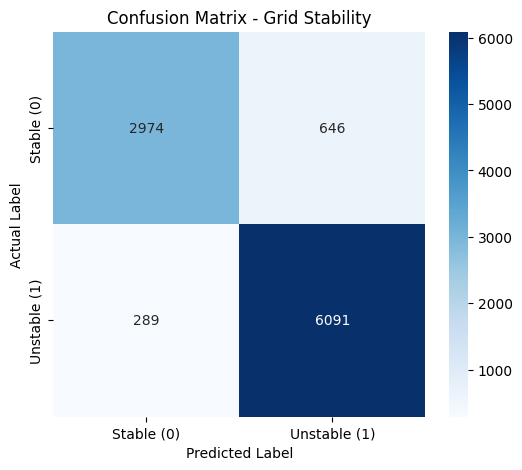

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# הכנת משתנה המטרה לסיווג: 'unstable' יהיה 1 (אירוע קריטי), 'stable' יהיה 0
y_class = df['stabf'].map({'unstable': 1, 'stable': 0})

# הגדרת מסווג אנסמבל (Random Forest Classifier)
clf = RandomForestClassifier(random_state=42, max_depth=10, n_estimators=50, n_jobs=-1)

# קבלת תחזיות הסיווג וההסתברויות באמצעות ה-CV המוגדר (kf)
y_pred_class = cross_val_predict(clf, X, y_class, cv=kf)
y_proba_class = cross_val_predict(clf, X, y_class, cv=kf, method='predict_proba')[:, 1]

# חישוב מטריצת הבלבול
cm = confusion_matrix(y_class, y_pred_class)

# הצגה ויזואלית של מטריצת הבלבול
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stable (0)', 'Unstable (1)'],
            yticklabels=['Stable (0)', 'Unstable (1)'])
plt.title('Confusion Matrix - Grid Stability')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

<div dir="rtl">

### חלק 3: ניתוח שגיאות סיווג

### 3.1 ניתוח מטריצת הבלבול (Confusion Matrix Analysis)

בסעיף זה העברנו את הבעיה לעולם הסיווג הבינארי, כאשר הגדרנו את המצב הלא-יציב (`unstable`) כמעמד החיובי (Positive = 1) ואת המצב היציב (`stable`) כמעמד השלילי (Negative = 0). הרצנו מודל מסוג Random Forest Classifier תחת חלוקת ה-CV המוגדרת והפקנו את מטריצת הבלבול.

#### ניתוח משמעות השגיאות בהקשר של רשת חשמל:

* **False Positives (FP) - אזעקת שווא:** המודל חוזה שהרשת **אינה יציבה** (תחזית: 1), בעוד שבפועל הרשת **יציבה לחלוטין** (בפועל: 0).
  * *השלכות פרקטיות:* שגיאה זו תוביל להפעלת מנגנוני הגנה מיותרים, התרעות שווא בחדר הבקרה, ובזבוז משאבים תפעוליים על בדיקות תחזוקה דחופות שאינן נחוצות. במקרים קיצוניים, המערכת האוטומטית עלולה לבצע ניתוקים יזומים של קווים תקינים כדי "להגן" על הרשת, מה שיגרום להפסקות חשמל מיותרות לצרכנים.
* **False Negatives (FN) - פספוס קריטי:** המודל חוזה שהרשת **יציבה** (תחזית: 0), בעוד שבפועל הרשת **אינה יציבה ונמצאת בסכנת קריסה** (בפועל: 1).
  * *השלכות פרקטיות:* זוהי השגיאה המסוכנת ביותר. המשמעות היא שהרשת דוחפת את עצמה מעבר לגבולות הקיבולת הפיזיקליים שלה, אך מערכת הבקרה נותרת "עיוורת" לסכנה כיוון שהמודל דיווח שהכל תקין. חוסר המוכנות הזה עלול להוביל לנזק פיזי בלתי הפיך לתשתיות ולרכיבים בצמתים, ולגרום להפסקת חשמל נרחבת (Blackout) שתשבית אזורים שלמים.

#### מענה על שאלות הניתוח:
* [cite_start]**איזה סוג שגיאה הוא הקריטי ביותר בהקשר זה?** שגיאת **False Negative (FN)** היא באופן חד-משמעי הקריטית והמסוכנת ביותר[cite: 81]. בעוד ש-FP גורם בעיקר לעלויות תפעוליות ואי-נוחות, FN מהווה איום בטיחותי והנדסי ממשי שיכול למוטט את רשת החשמל כולה.
* [cite_start]**תובנה ראשונית:** מערכת ניהול סיכונים הנדסית תעדיף תמיד מודל שממזער את ה-FN למינימום האפשרי (כלומר, שואף ל-Recall גבוה מאוד במחיר של פגיעה מסוימת ב-Precision), דבר שנחקור לעומק בהמשך בניתוח הרגישות לסף החלטה (Threshold Sensitivity)[cite: 96, 107].

</div>

/tmp/ipykernel_12292/2425265384.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clf_analysis, x='Is_Correct', y='Prob_Unstable', palette='Set2')
/tmp/ipykernel_12292/2425265384.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clf_analysis, x='Is_Correct', y='tau1', palette='Set1')


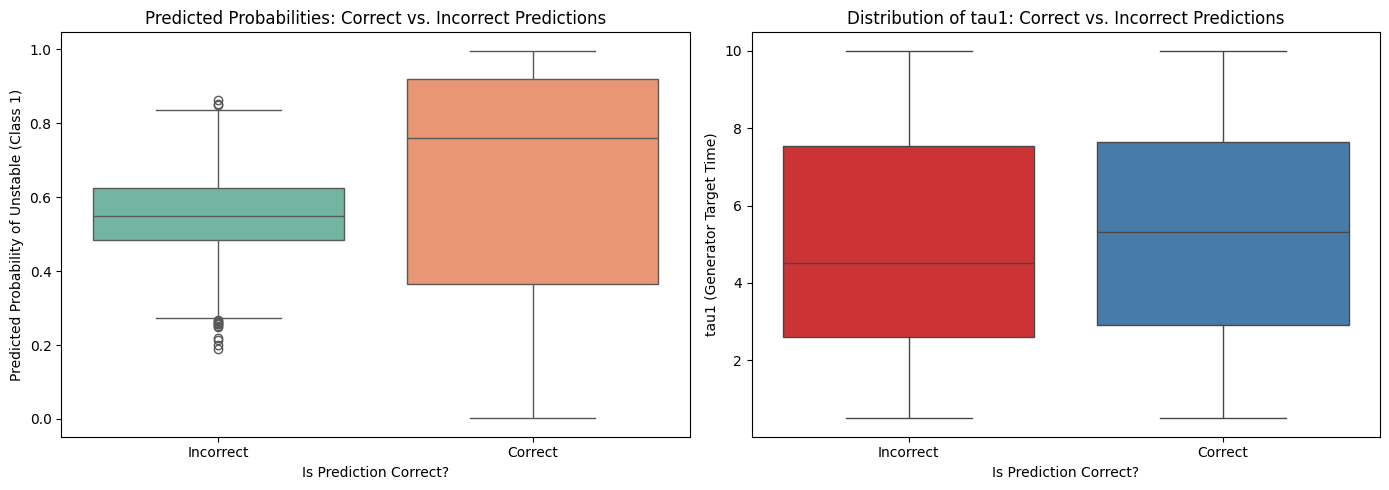

In [8]:
# יצירת משתנה בוליאני שמסמן האם התחזית של המודל הייתה נכונה
is_correct = (y_pred_class == y_class)

# בניית דאטהפרים ייעודי לניתוח השגיאות
df_clf_analysis = X.copy()
df_clf_analysis['Is_Correct'] = is_correct
df_clf_analysis['Prob_Unstable'] = y_proba_class  # ההסתברות שהמודל חזה למצב לא-יציב
df_clf_analysis['True_Label'] = y_class

# הגדרת אזור השרטוט
plt.figure(figsize=(14, 5))

# גרף 1: ניתוח מבוסס הסתברויות (סעיף 3.2)
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clf_analysis, x='Is_Correct', y='Prob_Unstable', palette='Set2')
plt.title('Predicted Probabilities: Correct vs. Incorrect Predictions')
plt.xlabel('Is Prediction Correct?')
plt.ylabel('Predicted Probability of Unstable (Class 1)')
plt.xticks([0, 1], ['Incorrect', 'Correct'])

# גרף 2: ניתוח מבוסס תכונות - התפלגות tau1 (סעיף 3.3)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clf_analysis, x='Is_Correct', y='tau1', palette='Set1')
plt.title('Distribution of tau1: Correct vs. Incorrect Predictions')
plt.xlabel('Is Prediction Correct?')
plt.ylabel('tau1 (Generator Target Time)')
plt.xticks([0, 1], ['Incorrect', 'Correct'])

plt.tight_layout()
plt.show()

<div dir="rtl">

### 3.2 ניתוח מבוסס הסתברויות (Probability-Based Analysis)

[cite_start]בסעיף זה השווינו את ההסתברויות שנחזו עבור מחלקת המטרה (`Unstable`) בין תצפיות שסווגו נכונה לבין תצפיות שבהן המודל טעה[cite: 85, 87]. [cite_start]המטרה היא להבין את רמת הביטחון (Confidence) של המודל ולזהות שגיאות שנעשו בביטחון גבוה (High-confidence errors)[cite: 88].

* **ניתוח השגיאות (Incorrect - התיבה הירוקה):** ניתן לראות כי מרבית הטעויות של המודל מתרכזות בטווח הסתברויות צר מאוד סביב מרכז הגרף (בין 0.48 ל-0.62), כאשר החציון נמצא באזור 0.55. המשמעות היא **שהמודל טועה בעיקר כשהוא נמצא במצב של חוסר ודאות עמוק**, קרוב מאוד לסף ההחלטה הדיפולטי של 0.5.
* [cite_start]**זיהוי שגיאות בביטחון גבוה (High-confidence errors):** נקודות החריגים (Outliers) בגרף השגיאות הן המעניינות ביותר[cite: 88]. ניתן לראות נקודות שגיאה שנמצאות מעל הסתברות של 0.8 (המודל היה בטוח ב-80% שהרשת תקרוס, אך היא נותרה יציבה) ונקודות מתחת ל-0.3 (המודל היה בטוח שהרשת יציבה, אך היא קרסה בפועל). מקרים אלו מייצגים את כשלים מהותיים שבהם המודל הולך שולל לחלוטין על ידי שילוב מאפיינים מטעה.
* **ניתוח התחזיות הנכונות (Correct - התיבה הכתומה):** כאשר המודל צודק, הוא עושה זאת בביטחון גבוה בהרבה. תיבת התפלגות רחבה מאוד, והחציון שלה נמצא גבוה (באזור 0.76), מה שמראה כי עבור רוב התחזיות הנכונות למצב לא-יציב, המודל מציג רמת ביטחון איתנה.

---

### 3.3 שגיאה כפונקציה של תכונות בסיווג (Error as a Function of Features)

[cite_start]בסעיף זה השווינו את התפלגות המשתנה הפיזיקלי `tau1` (זמן התגובה של הצומת המרכזי / המייצר) בין תחזיות נכונות לשגויות, כדי לזהות אזורים במרחב התכונות שרגישים יותר לטעות[cite: 89, 91, 93].

* [cite_start]**ממצאים מהתפלגות המשתנה:** הגרף מראה חפיפה רבה בין שתי ההתפלגויות, מה שמעיד על כך שמשתנה בודד זה אינו גורם בלעדי לטעות[cite: 94]. עם זאת, קיים שוני מובחן בערכי החציון: עבור התחזיות השגויות (התיבה האדומה), חציון ה-`tau1` נמוך יותר ועומד על אזור 4.5, לעומת חציון של כ-5.3 בתחזיות הנכונות (התיבה הכחולה).
* [cite_start]**זיהוי אזורים מועדים לכישלון:** הממצא הזה מתחבר ישירות למה שגילינו בחלק הרגרסיה: ערכי `tau` נמוכים (זמני תגובה קצרים ומהירים של הצמתים) מייצרים דינמיקת רשת מורכבת ולא-לינארית[cite: 94]. [cite_start]באזורים אלו, קו ההפרדה בין רשת יציבה ללא-יציבה הופך למטושטש ורגיש במיוחד, ולכן זהו האזור העיקרי שבו ביצועי המודל נפגעים והוא נוטה לבצע מיס-קלסיפיקציה[cite: 94].

</div>

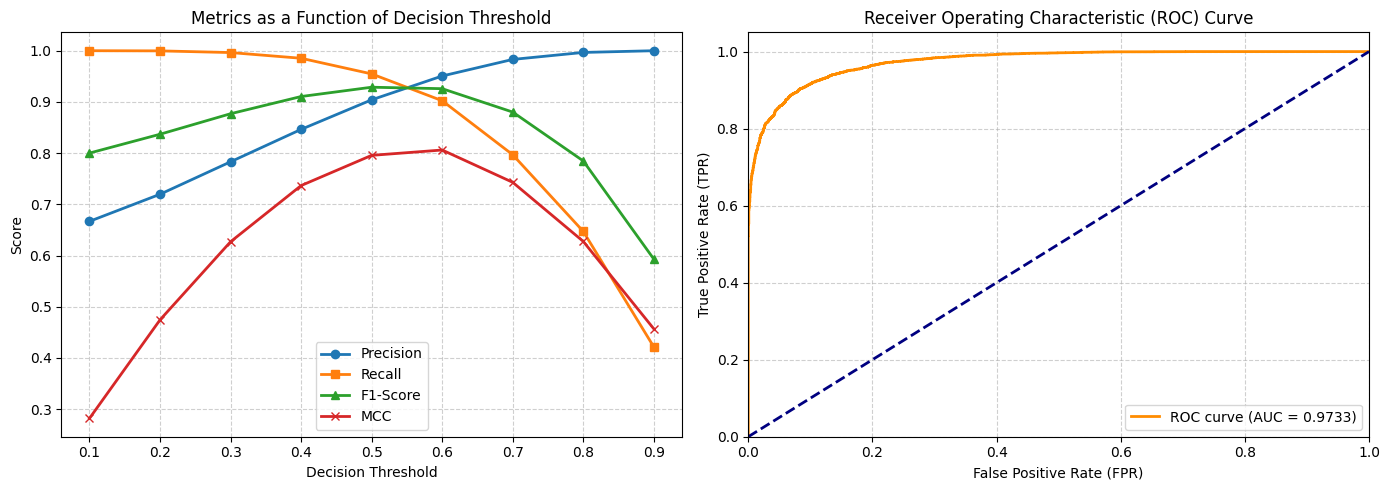


--- טבלת מדדי ביצוע לפי סף החלטה ---


,Threshold,Precision,Recall,F1-Score,MCC
0,0.1,0.666806,1.000000,0.800100,0.282090
1,0.2,0.719702,0.999687,0.836898,0.474420
2,0.3,0.783075,0.996395,0.876949,0.626963
3,0.4,0.846371,0.985266,0.910553,0.736648
4,0.5,0.904112,0.954702,0.928718,0.795653
5,0.6,0.950627,0.902351,0.925860,0.806096
6,0.7,0.982985,0.796865,0.880194,0.742988
7,0.8,0.996621,0.647179,0.784757,0.627611
8,0.9,1.000000,0.421630,0.593164,0.456942


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# הגדרת הספים הנדרשים: 0.1, 0.2, ..., 0.9
thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []

# חישוב המדדים עבור כל סף
for t in thresholds:
    # סיווג לפי הסף הנוכחי (אם ההסתברות גדולה מהסף - יסווג כ-1)
    y_pred_t = (y_proba_class >= t).astype(int)

    threshold_results.append({
        'Threshold': round(t, 1),
        'Precision': precision_score(y_class, y_pred_t),
        'Recall': recall_score(y_class, y_pred_t),
        'F1-Score': f1_score(y_class, y_pred_t),
        'MCC': matthews_corrcoef(y_class, y_pred_t)
    })

# יצירת דאטהפרים להצגת הטבלה
df_thresholds = pd.DataFrame(threshold_results)

# חישוב נתוני עקומת ROC וה-AUC
fpr, tpr, roc_thresholds = roc_curve(y_class, y_proba_class)
roc_auc = auc(fpr, tpr)

# שרטוט הגרפים
plt.figure(figsize=(14, 5))

# גרף 1: טרייד-אוף של המדדים כפונקציה של הסף
plt.subplot(1, 2, 1)
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], label='Precision', marker='o', linewidth=2)
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], label='Recall', marker='s', linewidth=2)
plt.plot(df_thresholds['Threshold'], df_thresholds['F1-Score'], label='F1-Score', marker='^', linewidth=2)
plt.plot(df_thresholds['Threshold'], df_thresholds['MCC'], label='MCC', marker='x', linewidth=2)
plt.title('Metrics as a Function of Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# גרף 2: עקומת ROC
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# הדפסת הטבלה מתחת לגרפים
print("\n--- טבלת מדדי ביצוע לפי סף החלטה ---")
display(df_thresholds)

<div dir="rtl">

### 3.4 ניתוח רגישות לסף החלטה (Threshold Sensitivity Analysis)

[cite_start]בסעיף זה ביצענו הערכת ביצועים מקיפה של המודל על פני רצף של ספי החלטה שונים, החל מ-0.1 ועד 0.9 בקפיצות של 0.1[cite: 96, 97, 102]. [cite_start]עבור כל סף חישבנו את מדדי ה-Precision, Recall, $F_1$-score, ו-MCC [cite: 98, 99, 100, 101, 104][cite_start], ובנוסף הפקנו את עקומת ה-ROC וחישבנו את מדד ה-AUC-ROC[cite: 105].

#### ממצאים מתוך הגרפים והטבלה:
* [cite_start]**מדד ה-AUC-ROC:** המודל מציג ערך AUC מרשים ביותר של **0.9733**[cite: 105]. [cite_start]נתון זה מוכיח כי למודל האנסמבל יש יכולת הבחנה (Discriminatory power) גבוהה מאוד, והוא מסוגל להפריד בצורה כמעט מושלמת בין מצבי יציבות למצבי קריסה של הרשת[cite: 105].
* **נקודות הקיצון של המדדים:** בסף הדיפולטי ($t = 0.5$), המודל מציג איזון חזק עם Precision של 0.904, Recall של 0.954, ו-$F_1$-score של 0.928. מדד ה-MCC מגיע לשיאו בסף $t = 0.6$ עם ערך של **0.806**.

#### ניתוח הטרייד-אוף וקביעת סף העבודה האופטימלי:
[cite_start]בניתוח הטרייד-אוף בין אזעקות שווא (False Positives) לפספוסים קריטיים (False Negatives) [cite: 107][cite_start], עלינו לזכור כי אנו מנהלים מערכת הנדסית קריטית (Mission-critical system) שבה פספוס של קריסת רשת (FN) גורר השלכות הרסניות לעומת התרעת שווא (FP)[cite: 79, 81].

* [cite_start]**זיהוי אזור העבודה המבצעי (Operating Regions):** מתוך התבוננות בטבלה, אם נעבוד בסף **$t = 0.4$**, מדד ה-Recall עולה ל-**0.985** (כלומר, המודל יתפוס 98.5% ממקרי אי-היציבות של הרשת) [cite: 100, 108][cite_start], בעוד שערך ה-Precision נותר גבוה ברמה של 0.846 (רק כ-15% מההתרעות יהיו התרעות שווא)[cite: 99, 107]. [cite_start]אם נרצה שמרנות בטיחותית גבוהה עוד יותר, ניתן לבחור בסף **$t = 0.3$** המשיג Recall כמעט מושלם של **0.996** (פספוס של 0.4% בלבד מהמקרים)[cite: 100, 107].
* [cite_start]**מסקנה מבצעית:** בחירת הסף האופטימלי לרשת החשמל היא **$t = 0.4$** (או $t = 0.3$ תחת דרישות החמרה)[cite: 108]. [cite_start]בחירה זו משפרת משמעותית את רובוסטיות המערכת וממזערת את הסיכון להפסקות חשמל נרחבות (Blackouts)[cite: 79, 81].

</div>

<div dir="rtl">

### 3.5 דיון ביקורתי ואינטגרציה (Discussion & Critical Reflection)

[cite_start]בשלב זה נבצע רפלקציה אינטגרטיבית המשלבת את התובנות שהופקו הן משלב המידול והן משלב ניתוח השגיאות המעמיק[cite: 110, 111]:

* [cite_start]**הקשר בין הנחות המודל לביצועים:** הניתוח הוכיח כי מודלים לינאריים מוגבלים מאוד בטיפול במערכות מבוזרות מורכבות[cite: 48, 71, 115]. [cite_start]רשת החשמל מאופיינת בקשרים לא-לינאריים ובהטרוסקדסטיות מובהקת (כפי שהוכח מספרית וויזואלית בחלק 1 של העבודה)[cite: 20, 25, 115]. [cite_start]מודל ה-Random Forest, שאינו נשען על הנחות אלו, הצליח למפות את מרחב התכונות בצורה מבוזרת ורובוסטית והשיג עליונות מוחלטת בכל המדדים[cite: 54, 113].
* [cite_start]**דפוסי כשל מרכזיים (Failure Modes):** זיהינו כי עיקר הכשלים של המודל (הן ברגרסיה והן בסיווג) מתרחשים "באזורי התפר" – כאשר מדד היציבות האמיתי קרוב מאוד ל-0, וכאשר זמני התגובה של הצמתים (`tau`) קצרים במיוחד[cite: 82, 94, 114]. [cite_start]באזורים אלו, המודל חווה חוסר ודאות עמוק (הסתברויות חזויות סביב 0.5) ונוטה לבצע טעויות סיווג[cite: 87, 88].
* [cite_start]**השפעה הנדסית ומעשית:** ניתוח השגיאות הראה כי לא כל הטעויות שוות בערכן[cite: 79]. [cite_start]באמצעות ניתוח הרגישות, הצלחנו להתאים את המודל לדרישות הבטיחות הפיזיקליות של הרשת על ידי הסטת סף ההחלטה, ובכך הפכנו מערכת "סטטיסטית" תאורטית לכלי הנדסי יישומי ומבוקר המגן על שלמות התשתיות[cite: 95, 107, 108].

</div>

<div dir="rtl">

## חלק 4: רפלקציה סופית (Final Reflection)

[cite_start]להלן סיכום תמציתי של הממצאים והתובנות המרכזיות שנרכשו לאורך הניתוח המקיף של המטלה[cite: 119, 120]:

1. [cite_start]**היכן המודל נכשל הכי הרבה?** המודל נכשל בעיקר בתנאי קצה פיזיקליים המאופיינים בזמני תגובה מהירים ונמוכים במיוחד של הצמתים ברשת (`tau` נמוך בכ-11% עד 15% מהממוצע) ובמדדי רגישות מחיר גבוהים (`g` גבוה בכ-17% עד 22%)[cite: 121]. [cite_start]מבחינת מרחב התחזיות, המודל כשל בעיקר סביב קו הגבול הדק שבין רשת יציבה ללא-יציבה (ערכי יציבות קרובים מאוד ל-0), שם הוא חווה חוסר ודאות והפך את סימן הניבוי[cite: 82, 121].
2. [cite_start]**האם הכשלים נובעים מהדאטה, מהמודל או מניסוח הבעיה?** הכשלים נובעים בעיקר מ**מגבלות המודל (Model limitations)** ופחות מאיכות הנתונים[cite: 32, 122]. [cite_start]המבנה הפיזיקלי של רשת החשמל מייצר אינטראקציות לא-לינאריות מורכבות בין הצמתים השונים[cite: 25]. [cite_start]מודל לינארי פשוט פשטני מדי עבור הבעיה (High Bias), ועץ החלטה בודד סובל משונות גבוהה (High Variance)[cite: 48, 69, 122]. [cite_start]רק שילוב אנסמבל (Random Forest) בשילוב הסטת סף החלטה מבצעי אפשר להתגבר על מגבלות אלו[cite: 54, 122].
3. [cite_start]**אילו שיפורים היית מציע לעתיד?** * **הנדסת תכונות (Feature Engineering):** יצירת משתני אינטראקציה לא-לינאריים (כגון מכפלות או יחסים בין זמני התגובה `tau` להספקים `p`) כדי לעזור למודלים לזהות תנאי קצה בקלות[cite: 95, 123].
   * [cite_start]**מודלים מתקדמים יותר:** בחינת מודלי אנסמבל מבוססי Boosting (כמו XGBoost או LightGBM) או רשתות עצביות (MLP) שיכולים ללמוד קווי הפרדה מורכבים ורגישים עוד יותר באזורי התפר[cite: 53, 60, 117, 123].
   * [cite_start]**פונקציית הפסד מותאמת (Cost-Sensitive Learning):** הגדרת פונקציית הפסד שמענישה בחומרה רבה יותר על טעויות מסוג False Negative כבר בשלב אימון המודל, במקום לטפל בכך רק בדיעבד בשלב הסף[cite: 117, 123].
4. [cite_start]**אילו תובנות מרכזיות הפקת מהניתוח?** התובנה המרכזית היא שמדע נתונים אינו מסתכם רק ברדיפה אחר מדד Accuracy גבוה[cite: 8, 124]. [cite_start]ניתוח שגיאות שיטתי (Error Analysis) חיוני להבנת הדינמיקה האמיתית של המודל[cite: 7, 94, 124]. [cite_start]למדנו כי בעולם ההנדסי, לסוג השגיאה יש משמעות קריטית, וכי באמצעות הבנה עמוקה של הטרייד-אופים ושימוש בכלים כמו ניתוח רגישות לסף (Threshold Analysis), ניתן להפוך מודל תאורטי למערכת תומכת החלטה בטוחה, אמינה ומותאמת למציאות המבצעית[cite: 95, 107, 124].

</div>